## Tutorial: comparing adaptive variational algorithms for Butyronitrile dissociation

In this tutorial we will use Kvantify's Qrunch to compute the dissociation reaction (C≡N) of the nitrile group in the burytonitril molecule. This system is currently relevant for applications in fields like Lithium ion batteries, as well as new solar cell technologies. We will employ different variational algorithms to approximate the ground state energies along the dissociation path and compare these to numerical solutions of the subspace under consideration.

We start with importing the relevant modules. All of the classes and methods we need will be found in the `qrunch` package. The documentation for Kvantify's Qrunch can be found [here](https://qrunch.docs.kvantify.net/index.html). It is useful to specify a path for the output as well, as this will be useful when building our chemistry problem. We also type in `qc.setup_logger()` which will allow us to output some simple logs and keep track of the progress when running our algorithms.

In [16]:
from pathlib import Path
import qrunch as qc

output_path = Path("output")
output_path.mkdir(exist_ok=True, parents=True)

qc.setup_logger()

## Hardware requirements

The basic version of this tutorial, i.e. without the modifications suggested as exercises below, requires at least 16GB of main memory and a should take up a negligible amount of disk space. Furthermore it is recommended to run this on a machine with at least 12 physical cores for the best user experience.

### Setting up the experiment

The starting point for our calculations is an .xyz file containing data for a model of the Butyronitrile dissociation reaction. For this, we will use a simplified model (`butyronitrile_dissociation.xyz`) where the reaction is composed of 9 different frames, or images. A more complete model (`butyronitrile_dissociation_large.xyz`) can also be used for a more detailed description of the reaction.

So the first step is to import the data. We generate a `Path` instance for it, which is an accepted input for our builders. 

In [17]:
reaction_path = Path("data/butyronitrile_dissociation.xyz")

Now we will build our reaction configuration. The first input to it is the reaction path. We also want to define a basis set for the molecular orbitals, and for simplicity we will use the minimal basis, STO-3G.

In all frames of the reaction, we will rely on [projective embedding theory](https://qrunch.docs.kvantify.net/docs/explanations/projective_embedding.html) (more on this in the following sections) to generate the environment through a mean-field approach, while adopting a wave function description of the embedded atoms. In this reaction, we want to focus on the dissociation of a Nitrogen from the molecule. The two atoms involved in this are `[C, N]`, with corresponding indices `[2, 3]` in the `.xyz` file (notice that the indices should be provided assuming 0-based indexing, as is the Python standard). So we can pass that information to define our embedded system in the reaction configuration as well.

In [18]:
reaction_configuration = qc.build_reaction_configuration(
    reaction=reaction_path,
    basis_set="sto3g",
    embedded_atoms=[2, 3],
)

### Creating the problem with the problem builder

We now come to the core of our problem definition. Here, all the information about the chemical system will be provided to a `problem_builder_creator`. In this tutorial, we will keep things simple and not provide too many specifications for this object. For more information on using the [fluent build pattern](https://qrunch.docs.kvantify.net/docs/explanations/builder_pattern.html) to construct the builder, and for details such as how to define the embedded orbital calculator, the orbital assignment, and more, check out other tutorials [COF-999](https://github.com/Kvantify/qrunch_tutorials/blob/main/cof-999-tutorial/cof-999-tutorial.ipynb) and [Dehalogenase](https://github.com/Kvantify/qrunch_tutorials/blob/main/dehalogenase-tutorial/dehalogenase_reaction_tutorial.ipynb).

From our main module, we will define the `problem_builder_creator` and specify that we want to calculate a `reaction_path`. This means that, when we later run the quantum algorithm for our problem, we will do so for all frames contained in the imported reaction file. After that, we specify the [even_handed approach](https://pubs.aip.org/aip/jcp/article/149/14/144101/196796/Even-handed-subsystem-selection-in-projection), which ensures consistent partitioning for orbitals across the reaction.

In [19]:
reaction_builder_creator = qc.problem_builder_creator().reaction_path().even_handed()

The only modification we are interested in making to our `problem_builder_creator` is specifying an active space. This helps us keep the problem tractable for this example by only taking into account a limited number of active spatial orbitals and active electrons. The size of the active space will also define how many qubits our system will employ in the quantum algorithm. The active space specifications are added to our reaction builder as a `problem_modifier`. Here, we will consider 8 active spatial orbitals and 8 active electrons, which is too small for accurate calculations, but enough for illustration purposes.

In this example, we have not specified any spin imbalance in the configuration. Therefore, the number of alpha and beta electrons assigned to the embedded atoms is the same and the embedded space spin difference will be 0. In the active space modification, we will then input the number of alpha electrons, and the number of beta electrons will be determined automatically by the embedded space spin difference and the specified number of alpha electrons. Thus we can construct the desired (8,8) active space by selecting the numbers as given in the following cell:

In [20]:
reaction_builder_creator = reaction_builder_creator.add_problem_modifier().active_space(
    number_of_active_spatial_orbitals=8,
    number_of_active_alpha_electrons=4,
)

When running calculations on embedded systems, it is useful to store the mean field results and orbital assignment details so that this information can be reused every time we run energy calculations. For this we can choose a `data_persister_manager`. Below, we first generate a directory where the persister files will be saved. Then we pass that as a path to the persister manager, along a customized extension and a `load_policy` (`"fallback"` means that, if the desired files are not already present in the folder, our program will generate them):

In [21]:
persister_path = output_path / "persister_data"
persister_path.mkdir(exist_ok=True, parents=True)

reaction_builder_creator = (
    reaction_builder_creator.choose_data_persister_manager().file_persister(
        directory=persister_path, extension=".qdk", load_policy="fallback"
    )
)

We are now ready to create the reaction builder:

In [22]:
reaction_builder = reaction_builder_creator.create()

And once the builder is set and build the even-handed reaction path problem by having the reaction configuration as the input. Here, we choose `build_restricted` to build the problem. This step can take up a few minutes to run on a laptop. The good news is that this needs only to be done once, since the next time the files will be ready in the folder and we simply need to load them!

In [23]:
reaction_problem = reaction_builder.build_restricted(reaction_configuration)

### Running quantum algorithms

We now turn to defining which quantum algorithm to run and what specifications we desire for it. 

This is where we will specify a `calculator_creator`. For more details on how to specify different elements of the calculator creator (e.g. the `estimator`, the `gate_selector` and so on), please check out the other tutorials. Here, we will keep the customization to a minimum. By not explicitly stating that we want to run our algorithm on quantum hardware, we will be relying on a classical simulation of the state vector for obtaining our results.

The only thing we want to specify at this point is that we want to run 25 iterations of our variational quantum algorithm, and we want to make sure that all iterations run irrespective of convergence criteria. This is done by defining some adaptive options which will be used throughout all calculations (notice that 25 is generally a small number for the maximum amount of iterations, but this is sufficient for illustration purposes in this tutorial - check out the exercises below to consider increasing this number):

In [ ]:
vqe_options = qc.options.IterativeVqeOptions(
    max_iterations=25, force_all_iterations=True
)

### Standard iterative VQE

The first quantum algorithm we want to run is an iterative or adaptive VQE (as opposed to a fixed-circuit VQE). So we call the `calculator_creator`, specify what type of algorithm it is, and choose `standard`. This means we will run an instance of an adaptive algorithm that relies on the ([FAST-VQE](https://qrunch.docs.kvantify.net/docs/explanations/adaptive_vqe.html)) gate selection scheme.

In [25]:
vqe_calculator_creator = qc.calculator_creator().vqe().iterative().standard()

It is always important to take some time to think about how to optimize parameters in our variational algorithm. Here, we will rely on the `last_variable_fft` as our `minimizer` choice. With this, we will only by optimizing the last-added gate parameter, in a greedy fashion. This also ensures that we will not spend too much time on classical optimization for this example. We can also plug in our `vqe_options` defined above at this point.

In [26]:
vqe_calculator_creator = (
    vqe_calculator_creator.choose_minimizer()
    .last_variable_fft()
    .with_options(vqe_options)
)

Finally, we create the vqe calculator, which is now ready to run.

In [27]:
vqe_calculator = vqe_calculator_creator.create()

To run the algorithm for our problem, we simply define a `results` object, and call the method `calculate` having as input our `reaction_problem`. This will run the VQE for all points in our reaction, and all relevant data of this run will be stored in the `results` (we will later extract this information and make some figures with it). If you have typed in the `qc.setup_logger()` above, you will get some basic information about the adaptive iterations and energy calculations too.

In [28]:
result = vqe_calculator.calculate(reaction_problem)

2025-10-27 10:24:45 [ESSENTIAL] (kvantify.qrunch): Run Adaptive VQE algorithm with 16 qubits:
2025-10-27 10:24:45 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 1 / 25: -19.56635055113172
2025-10-27 10:24:45 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 2 / 25: -19.57773043341234
2025-10-27 10:24:45 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 3 / 25: -19.587105020818907
2025-10-27 10:24:45 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 4 / 25: -19.592175681296837
2025-10-27 10:24:46 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 5 / 25: -19.597376745420945
2025-10-27 10:24:46 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 6 / 25: -19.599392337684836
2025-10-27 10:24:46 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 7 / 25: -19.601487109321038
2025-10-27 10:24:46 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 8 / 25: -19.602308851491568
2025-10-27 10:24:46 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 9 / 25: -

### Orbital optimization

The case above was simply one of the options we have for running a VQE. To explore further possibilities, let's now turn to algorithms that include orbital optimization. These employ parametrized rotations of the molecular orbitals at each iteration, on top of the standard adaptive scheme. Including orbital optimization in our algorithm generally provides better energy convergence, at the expense of having some classical overhead related to the optimization of the orbital rotation parameters.

Instead of adding the separate choices one by one, we will group all our specifications for the `calculator_creator` in a single cell. This is a good practice to keep our code lean and organized. The main difference here is that we need to ensure our VQE is `iterative_with_orbital_optimization`. We can then create the calculator and calculate the energies for the reaction problem. Notice that these calculations can take up to several minutes, since the orbital optimization step is more expensive. The results will be stored in `oo_result`.

In [29]:
oo_vqe_calculator = (
    qc.calculator_creator()
    .vqe()
    .iterative_with_orbital_optimization()
    .standard()
    .choose_minimizer()
    .last_variable_fft()
    .with_options(vqe_options)
    .create()
)
oo_result = oo_vqe_calculator.calculate(reaction_problem)

2025-10-27 10:25:00 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 1 / 25: -19.56635190741227
2025-10-27 10:25:00 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 2 / 25: -19.5777320886898
2025-10-27 10:25:01 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 3 / 25: -19.589148351186598
2025-10-27 10:25:01 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 4 / 25: -19.59422132885455
2025-10-27 10:25:01 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 5 / 25: -19.59942246049421
2025-10-27 10:25:02 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 6 / 25: -19.601438662387274
2025-10-27 10:25:03 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 7 / 25: -19.60353406674506
2025-10-27 10:25:03 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 8 / 25: -19.604064703701145
2025-10-27 10:25:04 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 9 / 25: -19.605495648804336
2025-10-27 10:25:05 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 10 /

Another option we can explore is to consider our system in the paired electron approximation framework. Here, we resort to [BEAST-VQE](https://qrunch.docs.kvantify.net/docs/explanations/beast.html), which does precisely that. In a real-world scenario, running BEAST-VQE means that we require half the number of total qubits as in the 'fermionic' case, since all excitations are paired. Combined with orbital optimization, this can be a good option for approximating the energies of simple systems. Further down, we will have a look at how these different methods compare to each other.

In [30]:
beast_oo_vqe_calculator = (
    qc.calculator_creator()
    .vqe()
    .iterative_with_orbital_optimization()
    .beast()
    .choose_minimizer()
    .last_variable_fft()
    .with_options(vqe_options)
    .create()
)
beast_oo_result = beast_oo_vqe_calculator.calculate(reaction_problem)

2025-10-27 10:32:10 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 1 / 25: -19.566351907412283
2025-10-27 10:32:10 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 2 / 25: -19.57773208868983
2025-10-27 10:32:10 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 3 / 25: -19.589148351182853
2025-10-27 10:32:11 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 4 / 25: -19.58968055766562
2025-10-27 10:32:11 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 5 / 25: -19.59114017460581
2025-10-27 10:32:11 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 6 / 25: -19.592622925160892
2025-10-27 10:32:11 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 7 / 25: -19.592869552990333
2025-10-27 10:32:11 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 8 / 25: -19.59329525538745
2025-10-27 10:32:11 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 9 / 25: -19.593728990400614
2025-10-27 10:32:11 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 10

### Configuration interaction

Finally, we can obtain some baseline data for the energies of our system. Since we are dealing with a fairly small active space, we can perform a classical numerical diagonalization of the active space under consideration. This is often referred in quantum chemistry as a Complete Active Space Configuration Interaction (CASCI) solution. For this we can define yet another calculator, where instead of using a VQE, we will call `configuration_interaction`. As before, we create the calculator and get the results for the reaction problem.

In [31]:
ci_calculator = (
    qc.calculator_creator().configuration_interaction().standard().create()
)
ci_result = ci_calculator.calculate(reaction_problem)

### Extracting results

We can now extract the energies from our `result` objects, and compare. For this, we will import `numpy` and `matplotlib.pyplot`. We can then obtain different properties and attributes, such as `electronic_energies` and `total_energies`. So we extract those and turn them into arrays.

In [32]:
import matplotlib.pyplot as plt

In [33]:
final_reaction_energies = result.total_energies.values
final_reaction_energies_oo = oo_result.total_energies.values
final_reaction_energies_beast_oo = beast_oo_result.total_energies.values
final_reaction_energies_ci = ci_result.total_energies.values

And we plot the energies for each different method:

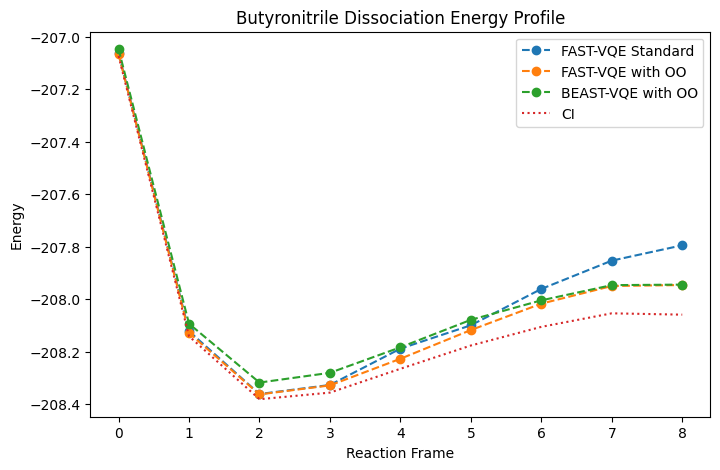

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(
    final_reaction_energies,
    label="FAST-VQE Standard",
    linestyle="--",
    marker="o",
)
plt.plot(
    final_reaction_energies_oo,
    label="FAST-VQE with OO",
    linestyle="--",
    marker="o",
)
plt.plot(
    final_reaction_energies_beast_oo,
    label="BEAST-VQE with OO",
    linestyle="--",
    marker="o",
)
plt.plot(
    final_reaction_energies_ci,
    label="CI",
    linestyle="dotted",
)
plt.xlabel("Reaction Frame")
plt.ylabel("Energy")
plt.title("Butyronitrile Dissociation Energy Profile")
plt.legend()
plt.show()

Here we see that the curves behave in a very similar manner, but still some distinctions can be noticed depending on which frame of the dissociation reaction we focus on. For instance, the FAST-VQE standard and FAST-VQE with Orbital Optimization behave well at the equilibrium configuration (i.e. the lower part of the curves). On the other hand, the BEAST-VQE calculation nearly matches the orbital optimized FAST-VQE run in the dissociation limit. As a baseline, we can see the best-case-scenario for this active space as the CI curve. Remember that, here, we have a trade-off between accuracy and computational cost, so we encourage you to explore which algorithm is best-suited for a particular chemical configuration.

Note that the FAST- and BEAST-VQE methods have different capabilities; for instance, they include different sets of operators in the gate pool for the adaptive run. Indeed, in the FAST-VQE approach we are including all possible single and double electron excitation gates. This means that, if we increase the number of iterations while running FAST-VQe, we could presumably expect to eventually achieve chemical accuracy in the energy error in the considered subspace. This is not the case for BEAST-VQE, where the paired-electron approximation is assumed and the number of available excitation operators is much smaller. 

### Now it's your turn

With the above results in mind, you are now in a good place to improve upon these results. A number of different options are available here:

1. In the calculations above, we resorted to a simplified description of the dissociation reaction; for a more detailed curve, you can try importing the file `butyronitrile_dissociation_large.xyz`.
2. Increase the active space; for practicality, we focused on a small number of active orbitals and electrons. To get more precise energies, you can increase that number. But remember that this could make numerical solutions from the full CI method intractable (that's what we want to use quantum computers for)!
3. For all the VQEs, we ran only 25 adaptive iterations. By calling `result.ground_state_problem_results[index]` we can actually check how the energy has converged for a single frame in the reaction (for details, again see the 'dehalogenase_reaction_tutorial.ipynb'). Increasing the number of iterations might provide a better approximation of the ground state energies in all cases (some methods might benefit more than others from this). You can also consider more sophisticated parameter optimization schemes.

We provide below a starting point for addressing item 3 based on the Standard FAST-VQE results:

In [35]:
equilibrium_configuration_index = 2
results_at_equilibrium = result.ground_state_problem_results[equilibrium_configuration_index].total_energy_per_macro_iteration_with_initial_energy_and_final_energy.values #type: ignore

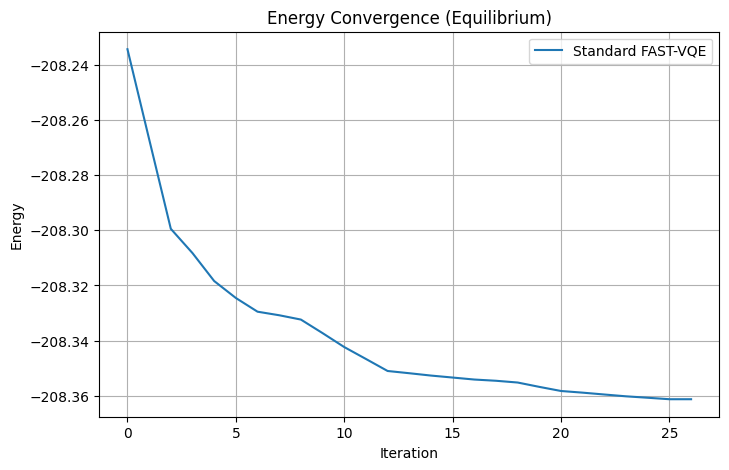

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(results_at_equilibrium, label="Standard FAST-VQE")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("Energy Convergence (Equilibrium)")
plt.legend()
plt.grid()
plt.show()